In [1]:
# Model 2: ISIC 2019 Skin Disease Classification using ANN

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load ISIC 2019 dataset files

metadata_path = "../dataset/ISIC_2019/ISIC_2019_Training_Metadata.csv"

groundtruth_path = "../dataset/ISIC_2019/ISIC_2019_Training_GroundTruth.csv"


# Read CSV files
metadata_df = pd.read_csv(metadata_path)

groundtruth_df = pd.read_csv(groundtruth_path)


# Display shapes
print("Metadata shape:", metadata_df.shape)
print("Ground Truth shape:", groundtruth_df.shape)


# Display first 5 rows
print("\nMetadata:")
display(metadata_df.head())

print("\nGround Truth:")
display(groundtruth_df.head())

Metadata shape: (25331, 5)
Ground Truth shape: (25331, 10)

Metadata:


,image,age_approx,anatom_site_general,lesion_id,sex
0,ISIC_0000000,55.0,anterior torso,NaN,female
1,ISIC_0000001,30.0,anterior torso,NaN,female
2,ISIC_0000002,60.0,upper extremity,NaN,female
3,ISIC_0000003,30.0,upper extremity,NaN,male
4,ISIC_0000004,80.0,posterior torso,NaN,male



Ground Truth:


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
print("Metadata columns:")
print(metadata_df.columns.tolist())

print("\nGround Truth columns:")
print(groundtruth_df.columns.tolist())

Metadata columns:
['image', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex']

Ground Truth columns:
['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']


In [5]:
# List of diagnosis columns
diagnosis_columns = [
    "MEL",
    "NV",
    "BCC",
    "AK",
    "BKL",
    "DF",
    "VASC",
    "SCC",
    "UNK"
]

# Convert one-hot encoded columns into a single diagnosis column
groundtruth_df["diagnosis"] = (
    groundtruth_df[diagnosis_columns]
    .idxmax(axis=1)
)

# Keep only image ID and diagnosis
groundtruth_clean = groundtruth_df[
    ["image", "diagnosis"]
]

# Merge metadata with diagnosis
data_isic = metadata_df.merge(
    groundtruth_clean,
    on="image",
    how="inner"
)

print("Merged dataset shape:", data_isic.shape)

# Display first 5 rows
display(data_isic.head())

Merged dataset shape: (25331, 6)


,image,age_approx,anatom_site_general,lesion_id,sex,diagnosis
0,ISIC_0000000,55.0,anterior torso,NaN,female,NV
1,ISIC_0000001,30.0,anterior torso,NaN,female,NV
2,ISIC_0000002,60.0,upper extremity,NaN,female,MEL
3,ISIC_0000003,30.0,upper extremity,NaN,male,NV
4,ISIC_0000004,80.0,posterior torso,NaN,male,MEL


In [6]:
# Check missing values
print("Missing values:")
print(data_isic.isnull().sum())

print("\nClass distribution:")
print(data_isic["diagnosis"].value_counts())

print("\nNumber of diagnosis classes:")
print(data_isic["diagnosis"].nunique())

Missing values:
image                     0
age_approx              437
anatom_site_general    2631
lesion_id              2084
sex                     384
diagnosis                 0
dtype: int64

Class distribution:
diagnosis
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64

Number of diagnosis classes:
8


In [7]:
# Create a copy for preprocessing
data_model2 = data_isic.copy()

# Drop identifier columns
data_model2 = data_model2.drop(
    columns=["image", "lesion_id"]
)

# Display remaining columns
print("Remaining columns:")
print(data_model2.columns.tolist())

print("\nDataset shape:", data_model2.shape)

display(data_model2.head())

Remaining columns:
['age_approx', 'anatom_site_general', 'sex', 'diagnosis']

Dataset shape: (25331, 4)


,age_approx,anatom_site_general,sex,diagnosis
0,55.0,anterior torso,female,NV
1,30.0,anterior torso,female,NV
2,60.0,upper extremity,female,MEL
3,30.0,upper extremity,male,NV
4,80.0,posterior torso,male,MEL


In [8]:
# Fill missing numerical values with the median
data_model2["age_approx"] = data_model2["age_approx"].fillna(
    data_model2["age_approx"].median()
)

# Fill missing categorical values with the most frequent value
data_model2["anatom_site_general"] = data_model2[
    "anatom_site_general"
].fillna(
    data_model2["anatom_site_general"].mode()[0]
)

data_model2["sex"] = data_model2["sex"].fillna(
    data_model2["sex"].mode()[0]
)

# Check remaining missing values
print("Missing values after preprocessing:")
print(data_model2.isnull().sum())

Missing values after preprocessing:
age_approx             0
anatom_site_general    0
sex                    0
diagnosis              0
dtype: int64


In [9]:
# Separate input features and target

X = data_model2.drop(columns=["diagnosis"])
y = data_model2["diagnosis"]

# One-hot encode categorical features
X_encoded = pd.get_dummies(
    X,
    columns=["anatom_site_general", "sex"],
    dtype=int
)

print("Feature dataset shape:", X_encoded.shape)

display(X_encoded.head())

Feature dataset shape: (25331, 11)


,age_approx,anatom_site_general_anterior torso,anatom_site_general_head/neck,anatom_site_general_lateral torso,anatom_site_general_lower extremity,anatom_site_general_oral/genital,anatom_site_general_palms/soles,anatom_site_general_posterior torso,anatom_site_general_upper extremity,sex_female,sex_male
0,55.0,1,0,0,0,0,0,0,0,1,0
1,30.0,1,0,0,0,0,0,0,0,1,0
2,60.0,0,0,0,0,0,0,0,1,1,0
3,30.0,0,0,0,0,0,0,0,1,0,1
4,80.0,0,0,0,0,0,0,1,0,0,1


In [10]:
# Create LabelEncoder
label_encoder_isic = LabelEncoder()

# Convert diagnosis names into numerical labels
y_encoded = label_encoder_isic.fit_transform(y)

# Show class mapping
print("Class mapping:")

for index, class_name in enumerate(label_encoder_isic.classes_):
    print(f"{index} = {class_name}")

print("\nNumber of classes:", len(label_encoder_isic.classes_))

Class mapping:
0 = AK
1 = BCC
2 = BKL
3 = DF
4 = MEL
5 = NV
6 = SCC
7 = VASC

Number of classes: 8


In [11]:
# First split:
# 80% for training + validation
# 20% for final testing

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training + Validation samples:", X_train_full.shape[0])
print("Final Test samples:", X_test.shape[0])

print("\nTraining + Validation shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Training + Validation samples: 20264
Final Test samples: 5067

Training + Validation shape: (20264, 11)
Test shape: (5067, 11)


In [12]:
# Second split:
# 80% actual training
# 20% validation

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Final Test samples:", X_test.shape[0])

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training samples: 16211
Validation samples: 4053
Final Test samples: 5067

Training shape: (16211, 11)
Validation shape: (4053, 11)
Test shape: (5067, 11)


In [13]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler for validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

print("\nTraining shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Scaling completed successfully!

Training shape: (16211, 11)
Validation shape: (4053, 11)
Test shape: (5067, 11)


In [14]:
# Convert scaled feature data to PyTorch tensors

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

# Convert labels to PyTorch tensors
y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("Training tensor shape:", X_train_tensor.shape)
print("Validation tensor shape:", X_val_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)

Training tensor shape: torch.Size([16211, 11])
Validation tensor shape: torch.Size([4053, 11])
Test tensor shape: torch.Size([5067, 11])


In [15]:
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Batch size
batch_size = 64

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 254
Validation batches: 64
Testing batches: 80


In [16]:
# Define the ISIC 2019 ANN model

class ISIC2019ANN(nn.Module):

    def __init__(self, input_size, num_classes):
        super(ISIC2019ANN, self).__init__()

        self.network = nn.Sequential(

            # First hidden layer
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Second hidden layer
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Third hidden layer
            nn.Linear(64, 32),
            nn.ReLU(),

            # Output layer
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# Define input and output sizes
input_size = X_train_scaled.shape[1]
num_classes = len(label_encoder_isic.classes_)

# Create the model
model_isic = ISIC2019ANN(
    input_size,
    num_classes
)

print(model_isic)

ISIC2019ANN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=8, bias=True)
  )
)


In [17]:
# Loss function
criterion_isic = nn.CrossEntropyLoss()

# Optimizer
optimizer_isic = torch.optim.Adam(
    model_isic.parameters(),
    lr=0.001
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [18]:
# Number of epochs
epochs_isic = 50

# Store training history
train_losses_isic = []
train_accuracies_isic = []

val_losses_isic = []
val_accuracies_isic = []

# Track best validation model
best_val_loss_isic = float("inf")
best_epoch_isic = 0


for epoch in range(epochs_isic):

    # =========================
    # TRAINING
    # =========================
    model_isic.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:

        # Reset gradients
        optimizer_isic.zero_grad()

        # Forward pass
        outputs = model_isic(inputs)

        # Calculate loss
        loss = criterion_isic(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_isic.step()

        # Store loss
        running_train_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Training metrics
    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    train_losses_isic.append(train_loss)
    train_accuracies_isic.append(train_accuracy)


    # =========================
    # VALIDATION
    # =========================
    model_isic.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            # Forward pass
            outputs = model_isic(inputs)

            # Calculate validation loss
            loss = criterion_isic(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Validation metrics
    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    val_losses_isic.append(val_loss)
    val_accuracies_isic.append(val_accuracy)


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_val_loss_isic:

        best_val_loss_isic = val_loss
        best_epoch_isic = epoch + 1

        torch.save(
            model_isic.state_dict(),
            "../models/ISIC_2019_best_model.pth"
        )


    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs_isic}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


print("\nTraining completed!")
print("Best epoch:", best_epoch_isic)
print("Best validation loss:", round(best_val_loss_isic, 4))

Epoch [1/50] | Train Loss: 1.3334 | Train Acc: 0.5361 | Val Loss: 1.2246 | Val Acc: 0.5559
Epoch [5/50] | Train Loss: 1.2222 | Train Acc: 0.5502 | Val Loss: 1.2092 | Val Acc: 0.5539
Epoch [10/50] | Train Loss: 1.2160 | Train Acc: 0.5528 | Val Loss: 1.2110 | Val Acc: 0.5601
Epoch [15/50] | Train Loss: 1.2122 | Train Acc: 0.5531 | Val Loss: 1.2056 | Val Acc: 0.5571
Epoch [20/50] | Train Loss: 1.2061 | Train Acc: 0.5542 | Val Loss: 1.2039 | Val Acc: 0.5593
Epoch [25/50] | Train Loss: 1.2039 | Train Acc: 0.5540 | Val Loss: 1.2031 | Val Acc: 0.5584
Epoch [30/50] | Train Loss: 1.2030 | Train Acc: 0.5554 | Val Loss: 1.2048 | Val Acc: 0.5591
Epoch [35/50] | Train Loss: 1.2004 | Train Acc: 0.5580 | Val Loss: 1.2021 | Val Acc: 0.5598
Epoch [40/50] | Train Loss: 1.1985 | Train Acc: 0.5572 | Val Loss: 1.2000 | Val Acc: 0.5621
Epoch [45/50] | Train Loss: 1.1964 | Train Acc: 0.5570 | Val Loss: 1.2024 | Val Acc: 0.5581
Epoch [50/50] | Train Loss: 1.1982 | Train Acc: 0.5577 | Val Loss: 1.2032 | Val Ac

In [19]:
# Load the best saved model

best_model_isic = ISIC2019ANN(
    input_size,
    num_classes
)

best_model_isic.load_state_dict(
    torch.load(
        "../models/ISIC_2019_best_model.pth",
        weights_only=True
    )
)

best_model_isic.eval()

print("Best model loaded successfully!")
print("Best epoch:", best_epoch_isic)

Best model loaded successfully!
Best epoch: 40


In [20]:
# Evaluate the best ISIC 2019 model on the test set

test_loss_isic = 0.0
test_correct_isic = 0
test_total_isic = 0

all_predictions_isic = []
all_labels_isic = []

best_model_isic.eval()

with torch.no_grad():

    for inputs, labels in test_loader:

        # Forward pass
        outputs = best_model_isic(inputs)

        # Calculate loss
        loss = criterion_isic(outputs, labels)

        test_loss_isic += loss.item() * inputs.size(0)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Calculate accuracy
        test_total_isic += labels.size(0)
        test_correct_isic += (
            predicted == labels
        ).sum().item()

        # Store predictions and actual labels
        all_predictions_isic.extend(
            predicted.cpu().numpy()
        )

        all_labels_isic.extend(
            labels.cpu().numpy()
        )


# Final test metrics
test_loss_isic = test_loss_isic / test_total_isic

test_accuracy_isic = (
    test_correct_isic / test_total_isic
)

print(
    f"Best Model Test Loss: "
    f"{test_loss_isic:.4f}"
)

print(
    f"Best Model Test Accuracy: "
    f"{test_accuracy_isic * 100:.2f} %"
)

Best Model Test Loss: 1.2138
Best Model Test Accuracy: 55.44 %


In [21]:
from sklearn.metrics import classification_report

# Get class names
class_names_isic = label_encoder_isic.classes_

# Print classification report
print(
    classification_report(
        all_labels_isic,
        all_predictions_isic,
        target_names=class_names_isic,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          AK       0.22      0.18      0.20       173
         BCC       0.30      0.34      0.32       665
         BKL       0.33      0.02      0.05       525
          DF       0.00      0.00      0.00        48
         MEL       0.37      0.15      0.22       904
          NV       0.64      0.93      0.76      2575
         SCC       0.00      0.00      0.00       126
        VASC       0.00      0.00      0.00        51

    accuracy                           0.55      5067
   macro avg       0.23      0.20      0.19      5067
weighted avg       0.47      0.55      0.48      5067



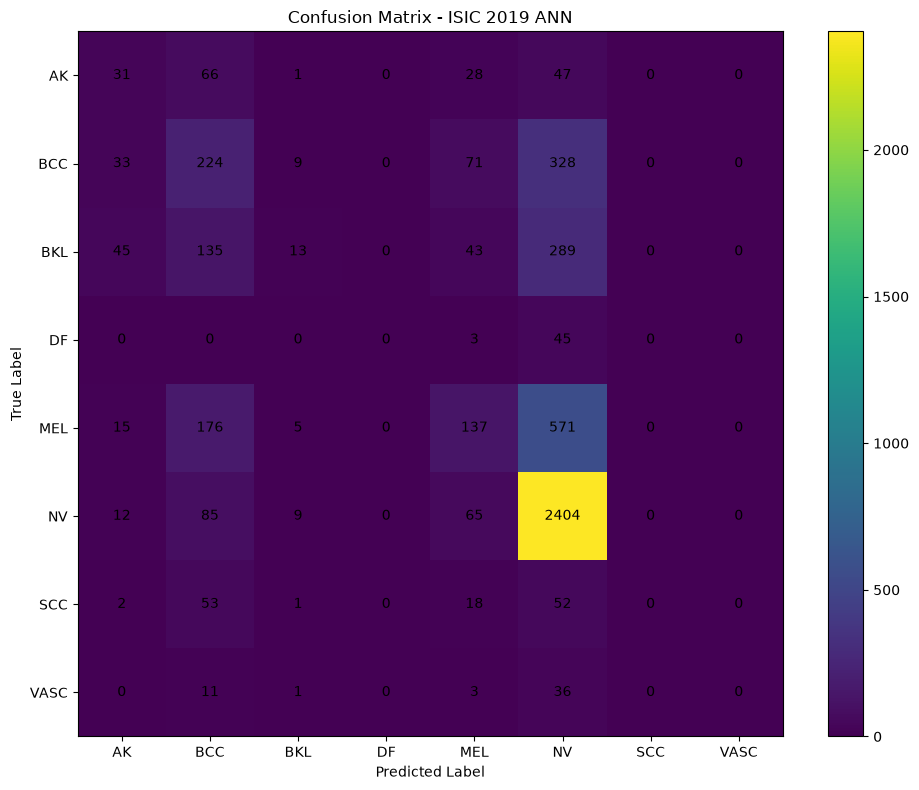

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm_isic = confusion_matrix(
    all_labels_isic,
    all_predictions_isic
)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

plt.imshow(cm_isic)

plt.colorbar()

plt.xticks(
    np.arange(len(class_names_isic)),
    class_names_isic
)

plt.yticks(
    np.arange(len(class_names_isic)),
    class_names_isic
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ISIC 2019 ANN")

# Add numbers inside the matrix
for i in range(len(class_names_isic)):
    for j in range(len(class_names_isic)):

        plt.text(
            j,
            i,
            str(cm_isic[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [23]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get all class indices
classes_isic = np.unique(y_train)

# Calculate class weights using training data only
class_weights_isic = compute_class_weight(
    class_weight="balanced",
    classes=classes_isic,
    y=y_train
)

# Convert to PyTorch tensor
class_weights_tensor_isic = torch.tensor(
    class_weights_isic,
    dtype=torch.float32
)

print("Class weights:\n")

for class_name, weight in zip(
    label_encoder_isic.classes_,
    class_weights_isic
):
    print(f"{class_name}: {weight:.4f}")

Class weights:

AK: 3.6511
BCC: 0.9531
BKL: 1.2069
DF: 13.2443
MEL: 0.7002
NV: 0.2459
SCC: 5.0407
VASC: 12.5085


In [24]:
# Create a fresh model for weighted training

weighted_model_isic = ISIC2019ANN(
    input_size,
    num_classes
)

# Use CrossEntropyLoss with class weights
weighted_criterion_isic = nn.CrossEntropyLoss(
    weight=class_weights_tensor_isic
)

# Create optimizer
weighted_optimizer_isic = torch.optim.Adam(
    weighted_model_isic.parameters(),
    lr=0.001
)

print("Weighted model created successfully!")
print("Loss function: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Weighted model created successfully!
Loss function: Weighted CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [25]:
# Number of epochs
weighted_epochs_isic = 50

# Store training history
weighted_train_losses_isic = []
weighted_train_accuracies_isic = []

weighted_val_losses_isic = []
weighted_val_accuracies_isic = []

# Track the best weighted model
best_weighted_val_loss_isic = float("inf")
best_weighted_epoch_isic = 0


for epoch in range(weighted_epochs_isic):

    # =========================
    # TRAINING
    # =========================
    weighted_model_isic.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:

        # Reset gradients
        weighted_optimizer_isic.zero_grad()

        # Forward pass
        outputs = weighted_model_isic(inputs)

        # Calculate weighted loss
        loss = weighted_criterion_isic(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        weighted_optimizer_isic.step()

        # Store loss
        running_train_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Training metrics
    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    weighted_train_losses_isic.append(train_loss)
    weighted_train_accuracies_isic.append(train_accuracy)


    # =========================
    # VALIDATION
    # =========================
    weighted_model_isic.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = weighted_model_isic(inputs)

            loss = weighted_criterion_isic(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Validation metrics
    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    weighted_val_losses_isic.append(val_loss)
    weighted_val_accuracies_isic.append(val_accuracy)


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_weighted_val_loss_isic:

        best_weighted_val_loss_isic = val_loss
        best_weighted_epoch_isic = epoch + 1

        torch.save(
            weighted_model_isic.state_dict(),
            "../models/ISIC_2019_weighted_best_model.pth"
        )


    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{weighted_epochs_isic}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


print("\nWeighted training completed!")
print("Best epoch:", best_weighted_epoch_isic)
print(
    "Best validation loss:",
    round(best_weighted_val_loss_isic, 4)
)

Epoch [1/50] | Train Loss: 1.9048 | Train Acc: 0.3944 | Val Loss: 1.8266 | Val Acc: 0.3178
Epoch [5/50] | Train Loss: 1.7805 | Train Acc: 0.3124 | Val Loss: 1.8077 | Val Acc: 0.3726
Epoch [10/50] | Train Loss: 1.7688 | Train Acc: 0.3371 | Val Loss: 1.7941 | Val Acc: 0.2198
Epoch [15/50] | Train Loss: 1.7604 | Train Acc: 0.3160 | Val Loss: 1.7889 | Val Acc: 0.3647
Epoch [20/50] | Train Loss: 1.7476 | Train Acc: 0.3289 | Val Loss: 1.7809 | Val Acc: 0.3679
Epoch [25/50] | Train Loss: 1.7537 | Train Acc: 0.3076 | Val Loss: 1.7825 | Val Acc: 0.3575
Epoch [30/50] | Train Loss: 1.7367 | Train Acc: 0.3353 | Val Loss: 1.7802 | Val Acc: 0.3175
Epoch [35/50] | Train Loss: 1.7354 | Train Acc: 0.3182 | Val Loss: 1.7789 | Val Acc: 0.3104
Epoch [40/50] | Train Loss: 1.7300 | Train Acc: 0.3224 | Val Loss: 1.7603 | Val Acc: 0.3210
Epoch [45/50] | Train Loss: 1.7282 | Train Acc: 0.3229 | Val Loss: 1.7623 | Val Acc: 0.3301
Epoch [50/50] | Train Loss: 1.7234 | Train Acc: 0.3243 | Val Loss: 1.7637 | Val Ac

In [26]:
# Create a fresh weighted model

best_weighted_model_isic = ISIC2019ANN(
    input_size,
    num_classes
)

# Load the best saved weights
best_weighted_model_isic.load_state_dict(
    torch.load(
        "../models/ISIC_2019_weighted_best_model.pth",
        weights_only=True
    )
)

best_weighted_model_isic.eval()

print("Best weighted model loaded successfully!")
print("Best epoch:", best_weighted_epoch_isic)

Best weighted model loaded successfully!
Best epoch: 49


In [27]:
# Evaluate the best weighted ISIC 2019 model

weighted_test_loss_isic = 0.0
weighted_test_correct_isic = 0
weighted_test_total_isic = 0

weighted_all_predictions_isic = []
weighted_all_labels_isic = []

best_weighted_model_isic.eval()

with torch.no_grad():

    for inputs, labels in test_loader:

        # Forward pass
        outputs = best_weighted_model_isic(inputs)

        # Calculate weighted loss
        loss = weighted_criterion_isic(outputs, labels)

        weighted_test_loss_isic += loss.item() * inputs.size(0)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Calculate accuracy
        weighted_test_total_isic += labels.size(0)
        weighted_test_correct_isic += (
            predicted == labels
        ).sum().item()

        # Store predictions and labels
        weighted_all_predictions_isic.extend(
            predicted.cpu().numpy()
        )

        weighted_all_labels_isic.extend(
            labels.cpu().numpy()
        )


# Final metrics
weighted_test_loss_isic = (
    weighted_test_loss_isic / weighted_test_total_isic
)

weighted_test_accuracy_isic = (
    weighted_test_correct_isic / weighted_test_total_isic
)

print(
    f"Weighted Model Test Loss: "
    f"{weighted_test_loss_isic:.4f}"
)

print(
    f"Weighted Model Test Accuracy: "
    f"{weighted_test_accuracy_isic * 100:.2f} %"
)

Weighted Model Test Loss: 1.7899
Weighted Model Test Accuracy: 26.58 %


In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        weighted_all_labels_isic,
        weighted_all_predictions_isic,
        target_names=class_names_isic,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          AK       0.15      0.63      0.25       173
         BCC       0.27      0.19      0.22       665
         BKL       0.17      0.12      0.14       525
          DF       0.03      0.67      0.06        48
         MEL       0.31      0.08      0.12       904
          NV       0.76      0.35      0.48      2575
         SCC       0.10      0.30      0.15       126
        VASC       0.01      0.20      0.03        51

    accuracy                           0.27      5067
   macro avg       0.23      0.32      0.18      5067
weighted avg       0.50      0.27      0.32      5067



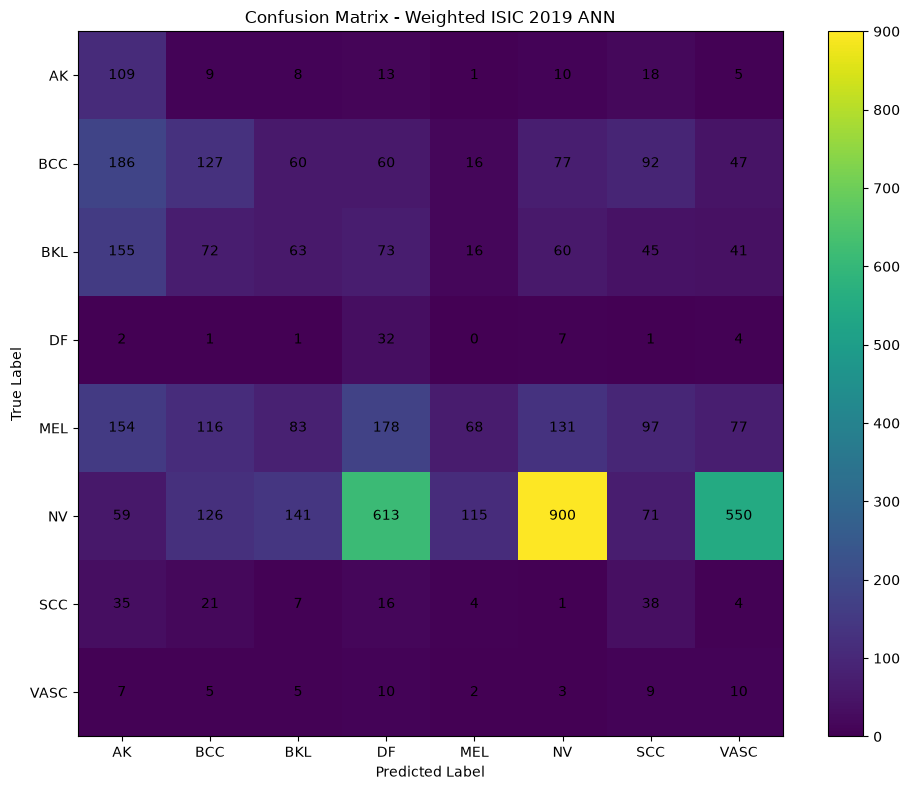

In [29]:
# Create confusion matrix for weighted ISIC 2019 ANN

cm_weighted_isic = confusion_matrix(
    weighted_all_labels_isic,
    weighted_all_predictions_isic
)

plt.figure(figsize=(10, 8))

plt.imshow(cm_weighted_isic)
plt.colorbar()

plt.xticks(
    np.arange(len(class_names_isic)),
    class_names_isic
)

plt.yticks(
    np.arange(len(class_names_isic)),
    class_names_isic
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Weighted ISIC 2019 ANN")

# Add values inside the matrix
for i in range(len(class_names_isic)):
    for j in range(len(class_names_isic)):
        plt.text(
            j,
            i,
            str(cm_weighted_isic[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import torch

# Original class weights
original_weights_isic = class_weights_isic

# Soften the class weights using square root
moderated_weights_isic = np.sqrt(original_weights_isic)

# Normalize so the average weight remains approximately 1
moderated_weights_isic = (
    moderated_weights_isic /
    moderated_weights_isic.mean()
)

# Convert to PyTorch tensor
moderated_weights_tensor_isic = torch.tensor(
    moderated_weights_isic,
    dtype=torch.float32
)

print("Moderated class weights:\n")

for class_name, weight in zip(
    class_names_isic,
    moderated_weights_isic
):
    print(f"{class_name}: {weight:.4f}")

Moderated class weights:

AK: 1.0371
BCC: 0.5299
BKL: 0.5963
DF: 1.9752
MEL: 0.4542
NV: 0.2692
SCC: 1.2186
VASC: 1.9196


In [31]:
# Create a new ANN model

moderated_model_isic = ISIC2019ANN(
    input_size,
    num_classes
)

# Use moderated class weights
moderated_criterion_isic = nn.CrossEntropyLoss(
    weight=moderated_weights_tensor_isic
)

# Adam optimizer
moderated_optimizer_isic = optim.Adam(
    moderated_model_isic.parameters(),
    lr=0.001
)

print("Moderately Weighted ISIC 2019 ANN created successfully!")

print("\nLoss function:")
print("CrossEntropyLoss with moderated class weights")

print("\nOptimizer:")
print("Adam")

print("\nLearning rate:")
print(0.001)

Moderately Weighted ISIC 2019 ANN created successfully!

Loss function:
CrossEntropyLoss with moderated class weights

Optimizer:
Adam

Learning rate:
0.001


In [32]:
# Number of epochs
moderated_epochs_isic = 50

# Store training history
moderated_train_losses_isic = []
moderated_train_accuracies_isic = []

moderated_val_losses_isic = []
moderated_val_accuracies_isic = []

# Track best model
best_moderated_val_loss_isic = float("inf")
best_moderated_epoch_isic = 0


for epoch in range(moderated_epochs_isic):

    # =========================
    # TRAINING
    # =========================
    moderated_model_isic.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:

        # Reset gradients
        moderated_optimizer_isic.zero_grad()

        # Forward pass
        outputs = moderated_model_isic(inputs)

        # Calculate loss
        loss = moderated_criterion_isic(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        moderated_optimizer_isic.step()

        # Store loss
        running_train_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Training metrics
    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    moderated_train_losses_isic.append(train_loss)
    moderated_train_accuracies_isic.append(train_accuracy)


    # =========================
    # VALIDATION
    # =========================
    moderated_model_isic.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = moderated_model_isic(inputs)

            loss = moderated_criterion_isic(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Validation metrics
    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    moderated_val_losses_isic.append(val_loss)
    moderated_val_accuracies_isic.append(val_accuracy)


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_moderated_val_loss_isic:

        best_moderated_val_loss_isic = val_loss
        best_moderated_epoch_isic = epoch + 1

        torch.save(
            moderated_model_isic.state_dict(),
            "../models/ISIC_2019_moderated_best_model.pth"
        )


    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{moderated_epochs_isic}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


print("\nModerated weighted training completed!")
print("Best epoch:", best_moderated_epoch_isic)
print(
    "Best validation loss:",
    round(best_moderated_val_loss_isic, 4)
)

Epoch [1/50] | Train Loss: 1.7087 | Train Acc: 0.5163 | Val Loss: 1.6138 | Val Acc: 0.5349
Epoch [5/50] | Train Loss: 1.6069 | Train Acc: 0.5332 | Val Loss: 1.6023 | Val Acc: 0.5248
Epoch [10/50] | Train Loss: 1.5889 | Train Acc: 0.5344 | Val Loss: 1.5955 | Val Acc: 0.5349
Epoch [15/50] | Train Loss: 1.5848 | Train Acc: 0.5333 | Val Loss: 1.5897 | Val Acc: 0.5307
Epoch [20/50] | Train Loss: 1.5795 | Train Acc: 0.5343 | Val Loss: 1.5909 | Val Acc: 0.5221
Epoch [25/50] | Train Loss: 1.5780 | Train Acc: 0.5343 | Val Loss: 1.5872 | Val Acc: 0.5312
Epoch [30/50] | Train Loss: 1.5706 | Train Acc: 0.5371 | Val Loss: 1.5877 | Val Acc: 0.5438
Epoch [35/50] | Train Loss: 1.5672 | Train Acc: 0.5302 | Val Loss: 1.5868 | Val Acc: 0.5364
Epoch [40/50] | Train Loss: 1.5675 | Train Acc: 0.5365 | Val Loss: 1.5820 | Val Acc: 0.5398
Epoch [45/50] | Train Loss: 1.5662 | Train Acc: 0.5351 | Val Loss: 1.5797 | Val Acc: 0.5329
Epoch [50/50] | Train Loss: 1.5598 | Train Acc: 0.5351 | Val Loss: 1.5806 | Val Ac

In [33]:
# Create a fresh model

best_moderated_model_isic = ISIC2019ANN(
    input_size,
    num_classes
)

# Load the best saved model
best_moderated_model_isic.load_state_dict(
    torch.load(
        "../models/ISIC_2019_moderated_best_model.pth",
        weights_only=True
    )
)

best_moderated_model_isic.eval()

print("Best moderated model loaded successfully!")
print("Best epoch:", best_moderated_epoch_isic)

Best moderated model loaded successfully!
Best epoch: 45


In [34]:
# Evaluate the best moderated ISIC 2019 model

moderated_test_loss_isic = 0.0
moderated_test_correct_isic = 0
moderated_test_total_isic = 0

moderated_all_predictions_isic = []
moderated_all_labels_isic = []

best_moderated_model_isic.eval()

with torch.no_grad():

    for inputs, labels in test_loader:

        # Forward pass
        outputs = best_moderated_model_isic(inputs)

        # Calculate loss
        loss = moderated_criterion_isic(outputs, labels)

        moderated_test_loss_isic += loss.item() * inputs.size(0)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Calculate accuracy
        moderated_test_total_isic += labels.size(0)

        moderated_test_correct_isic += (
            predicted == labels
        ).sum().item()

        # Store predictions and actual labels
        moderated_all_predictions_isic.extend(
            predicted.cpu().numpy()
        )

        moderated_all_labels_isic.extend(
            labels.cpu().numpy()
        )


# Calculate final metrics
moderated_test_loss_isic = (
    moderated_test_loss_isic /
    moderated_test_total_isic
)

moderated_test_accuracy_isic = (
    moderated_test_correct_isic /
    moderated_test_total_isic
)


print(
    f"Moderated Model Test Loss: "
    f"{moderated_test_loss_isic:.4f}"
)

print(
    f"Moderated Model Test Accuracy: "
    f"{moderated_test_accuracy_isic * 100:.2f} %"
)

Moderated Model Test Loss: 1.5941
Moderated Model Test Accuracy: 53.58 %


In [35]:
from sklearn.metrics import classification_report

print(
    classification_report(
        moderated_all_labels_isic,
        moderated_all_predictions_isic,
        target_names=class_names_isic,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          AK       0.18      0.41      0.25       173
         BCC       0.29      0.26      0.27       665
         BKL       0.23      0.12      0.16       525
          DF       0.00      0.00      0.00        48
         MEL       0.33      0.16      0.22       904
          NV       0.69      0.87      0.77      2575
         SCC       0.15      0.12      0.13       126
        VASC       0.00      0.00      0.00        51

    accuracy                           0.54      5067
   macro avg       0.23      0.24      0.23      5067
weighted avg       0.48      0.54      0.50      5067



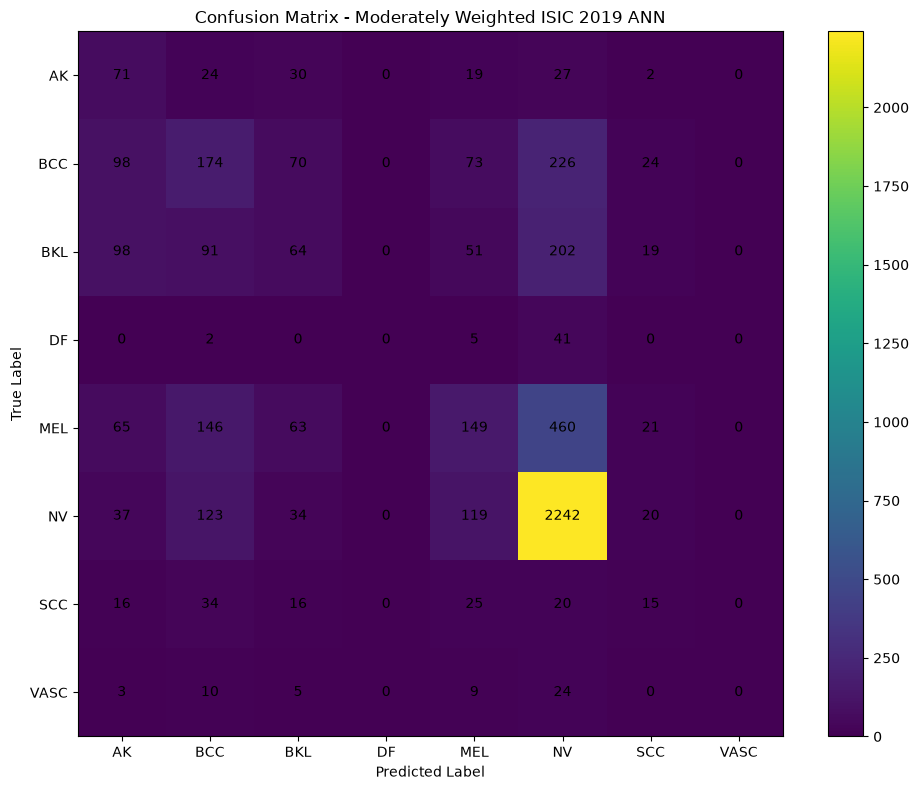

In [36]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm_moderated_isic = confusion_matrix(
    moderated_all_labels_isic,
    moderated_all_predictions_isic
)

plt.figure(figsize=(10, 8))

plt.imshow(cm_moderated_isic)
plt.colorbar()

plt.xticks(
    np.arange(len(class_names_isic)),
    class_names_isic
)

plt.yticks(
    np.arange(len(class_names_isic)),
    class_names_isic
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Moderately Weighted ISIC 2019 ANN")

# Add values inside the matrix
for i in range(len(class_names_isic)):
    for j in range(len(class_names_isic)):
        plt.text(
            j,
            i,
            str(cm_moderated_isic[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()